# Intelligent Agents: Reflex-Based Agents for the Vacuum-cleaner World

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]


## Learning Outcomes

- Design and build a simulation environment that models sensor inputs, actuator effects, and performance measurement.
- Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
- Practice how the environment and the agent function interact.
- Analyze agent performance through controlled experiments across different environment configurations.
- Graduate Students: Develop strategies for handling uncertainty and imperfect information in autonomous agent systems.

## Instructions

Total Points: 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

### AI Use

Here are some guidelines that will make it easier for you:

- **Don't:** Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
- **Don't:** Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
- **Do:** Use AI for debugging and letting it explain code and concepts from class.

### Using Visual Studio Code

Follow [HOWTO Setup the Used Tools] to set up your Jupyter Notebook environment.
You can use `Export` (click on `...` in the menu bar) in VS Code to save your notebook as a HTML file. Don't forget to run all blocks before, so the HTML file contains the output of the executed code.

### Using Google Colab

In Colab you need to save the notebook on GoogleDrive to work with it. For this you need to mount your google dive and change to the correct directory. The following code will try to do this if you are on Colab.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

Once you are done with the assignment and have run all code blocks using `Runtime/Run all`, you can convert your notebook on GoogleDrive into HTML
using: [Convert a Jupyter Notebook to HTML using Colab](https://colab.research.google.com/github/mhahsler/Introduction_to_Artificial_Intelligence/blob/master/HOWTOs/colab_to_html.ipynb).


## Introduction

In this assignment you will implement a simulator environment for an automatic vacuum cleaner robot, a set of different reflex-based agent programs, and perform a comparison study for cleaning a single room. Focus on the **cleaning phase** which starts when the robot is activated and ends when the last dirty square in the room has been cleaned. Someone else will take care of the agent program needed to navigate back to the charging station after the room is clean.

## PEAS description of the cleaning phase

The PEAS description is used in the design phase for an intelligent agent. Make sure your implementations follow this description:

- **Performance Measure:** Each action costs 1 energy unit. The performance is measured as the sum of the energy units used to clean the whole room.

- **Environment:** A room with $n \times n$ squares where $n = 5$. Dirt is randomly placed on each square with probability $p = 0.2$. For simplicity, you can assume that the agent knows the size and the layout of the room (i.e., it knows $n$). To start, the agent is placed on a random square.

- **Actuators:** The agent can clean the current square (action `suck`) or move to an adjacent square by going `north`, `east`, `south`, or `west`.

- **Sensors:** Four bumper sensors, one for north, east, south, and west; a dirt sensor reporting dirt in the current square.


## The agent program for a simple randomized agent

To show the structure of an agent program, I implement here a simple randomized agent that chooses its actions randomly.

The agent program is implemented as a function that gets sensor information (the current percepts) as the arguments.
We will use the parameters:

- `bumpers`: A dictionary with boolean entries for the for bumper sensors `north`, `east`, `west`, `south`. E.g., if the agent is on the north-west corner, `bumpers` will be `{"north" : True, "east" : False, "south" : False, "west" : True}`.
- `dirty`: A boolean representing the dirt sensor.

The agent returns the chosen action as a string.

Here is an example implementation for the agent program of a simple randomized agent:


In [3]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "numpy>=1.26,<3"

In [2]:
import numpy as np

actions = ["north", "east", "west", "south", "suck"]

def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [3]:
# define percepts (current location is NW corner and it is dirty)
bumpers = {"north" : True, "east" : False, "south" : False, "west" : True}
dirty = True

# call agent program function with percepts and it returns an action
simple_randomized_agent(bumpers, dirty)

np.str_('east')

**Note:** This is not a rational intelligent agent. It ignores its sensors and may bump into a wall repeatedly or not clean a dirty square. You will be asked to implement rational agents below.


## Simple environment example

I show here how to implement a simple simulation environment that supplies the agent program with its percepts and evaluates the agent's actions.
As an example, I implement a room of infinite in size (bumpers are always `False`) where every square is always dirty, even if the agent cleans it. The environment function returns a different performance measure than the one specified in the PEAS description! Since the room is infinite and all squares are constantly dirty, the agent can never clean the whole room. Your implementation needs to implement the **correct performance measure.** The energy budget of the agent is specified as `max_steps`.


In [4]:
def simple_environment(agent_function, max_steps, verbose = True):
    num_cleaned = 0
    
    for i in range(max_steps):
        dirty = True
        bumpers = {"north" : False, "south" : False, "west" : False, "east" : False}

        action = agent_function(bumpers, dirty)
        if (verbose): print("step", i , "- action:", action) 
        
        if (action == "suck"): 
            num_cleaned = num_cleaned + 1
        
    return num_cleaned
        


Do one simulation run with a simple randomized agent that has enough energy for 20 steps.


In [5]:
simple_environment(simple_randomized_agent, max_steps = 20)

step 0 - action: north
step 1 - action: east
step 2 - action: north
step 3 - action: west
step 4 - action: west
step 5 - action: east
step 6 - action: suck
step 7 - action: suck
step 8 - action: suck
step 9 - action: north
step 10 - action: east
step 11 - action: south
step 12 - action: north
step 13 - action: west
step 14 - action: west
step 15 - action: west
step 16 - action: west
step 17 - action: north
step 18 - action: east
step 19 - action: west


3

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
   - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
   - Do not show debugging output or include an excessive amount of output.
   - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.


## Task 1: Implement a simulation environment [20 Points]

The simple environment above is not very realistic. Your environment simulator needs to follow the PEAS description from above. It needs to:

- Initialize the environment by storing the state of each square (clean/dirty) and making some dirty. ([Help with random numbers and arrays in Python])
- Keep track of the agent's position.
- Call the agent function repeatedly and provide the agent function with the sensor inputs.
- React to the agent's actions. E.g, by removing dirt from a square or moving the agent around unless there is a wall in the way.
- Keep track of the performance measure. That is, track the agent's actions until all dirty squares are clean and count the number of actions it takes the agent to complete the task.

The easiest implementation for the environment is to hold an 2-dimensional array to represent if squares are clean or dirty and to call the agent function in a loop until all squares are clean or a predefined number of steps have been reached (i.e., the robot runs out of energy).

The simulation environment should be a function like the `simple_environment()` and needs to work with the simple randomized agent program from above. **Use the same environment for all your agent implementations in the tasks below.**

_Note on debugging:_ Debugging can be difficult. Here are a few options:

- Make sure your environment prints enough information when you use `verbose = True`.
- VSCode also provides a very good interactive Python debugger for notebooks. Read the [HOWTO on debugging](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/debugging_in_notebooks.ipynb) for more details.
- Another very useful debugging help is to implement a function that the environment can use to displays the room with dirt and the current position of the robot at every step. You can use simple characters for dirt and the robot location.


<h2><b>PEAS


- Environment (Môi trường):
  - Lưới kích thước n × n (mặc định n = 5, nhưng hàm cần nhận tham số n để Task 4 có thể chạy với 10 × 10, 100 ×
    100).
  - Xác suất mỗi ô có bụi ngẫu nhiên ban đầu là p = 0.2.
  - Vị trí bắt đầu của robot được chọn ngẫu nhiên trên lưới.
- Sensors (Cảm biến truyền cho tác tử mỗi bước):
  - bumpers: Dictionary gồm 4 giá trị boolean {"north": bool, "east": bool, "south": bool, "west": bool}. Giá trị
    là True khi ô kế tiếp theo hướng đó là tường (vượt ra ngoài biên lưới), ngược lại là False.
  - dirty: Boolean biểu thị ô hiện tại robot đang đứng có bẩn hay không (True nếu ô có bụi, False nếu sạch).
- Actuators (Phản ứng với hành động của tác tử):
  - "suck": Hút bụi tại ô hiện tại → chuyển trạng thái ô đó từ bẩn thành sạch.
  - "north", "south", "east", "west": Di chuyển robot sang ô kế tiếp. Nếu va vào tường (hướng đó có biên), robot
    sẽ đứng yên tại chỗ.
- Performance Measure (Đo lường hiệu năng):
  - Mỗi hành động tốn 1 đơn vị năng lượng (1 cost).
  - Đo tổng số bước/năng lượng tiêu thụ để làm sạch toàn bộ căn phòng.
  - Dừng khi: Tất cả các ô đã sạch HOẶC đạt giới hạn số bước max_steps (hết pin).


In [6]:
# Display environment with grids
def display_environment(environment, robot_position=(-1, -1)):
    print("Environment:")
    for i in range(environment.shape[0]):
        for j in range(environment.shape[1]):
            if (i, j) == robot_position:
                # In màu xanh cho vị trí robot
                print("\033[92mR\033[0m", end=" ")
            elif environment[i, j] == 1:
                # In màu đỏ cho ô bẩn
                print("\033[91m1\033[0m", end=" ")
            else:
                print("0", end=" ")
        print()

In [7]:
# Logs steps and actions taken by the agent
def display_step(step, current_pos, action, dirty, robot_position):
    print(f"Step {step}: Pos ({current_pos[0]}, {current_pos[1]}) -> Action: {action:5s} | Sensed Dirty: {str(dirty):5s} -> NewPos ({robot_position[0]}, {robot_position[1]})")

In [8]:
# Your code and description goes here
def standard_environment(agent_function, n=5, p=0.2, max_steps=1000, verbose=False):
    # 1. Khởi tạo grid phòng và vị trí ban đầu của robot
    grids = np.random.choice([0, 1], size=(n, n), p=[1-p, p])  # 0: clean, 1: dirty
    robot_position = tuple(np.random.randint(0, n, size=2))

    if verbose:
        print("=== INITIAL ENVIRONMENT ===")
        display_environment(grids)
        print("\n=== INITIAL ENVIRONMENT WITH ROBOT ===")
        display_environment(grids, robot_position)
        print()

    # Kiểm tra nếu phòng sạch ngay từ đầu
    if np.all(grids == 0):
        if verbose:
            print("Room is already clean!")
        return 0

    # 2. Vòng lặp mô phỏng
    step = 0
    for step in range(max_steps):
        current_pos = robot_position

        # a. Cảm biến bumpers và dirty tại vị trí hiện tại
        bumpers = {
            "north": current_pos[0] == 0,
            "south": current_pos[0] == n - 1,
            "west": current_pos[1] == 0,
            "east": current_pos[1] == n - 1
        }
        dirty = (grids[current_pos] == 1)

        # b. Lấy action từ agent
        action = agent_function(bumpers, dirty)

        # c. Xử lý action
        if action == "suck":
            if dirty:
                grids[current_pos] = 0
        elif action == "north" and not bumpers["north"]:
            robot_position = (current_pos[0] - 1, current_pos[1])
        elif action == "south" and not bumpers["south"]:
            robot_position = (current_pos[0] + 1, current_pos[1])
        elif action == "west" and not bumpers["west"]:
            robot_position = (current_pos[0], current_pos[1] - 1)
        elif action == "east" and not bumpers["east"]:
            robot_position = (current_pos[0], current_pos[1] + 1)

        # d. In log nếu verbose=True
        if verbose:
            display_step(step, current_pos, action, dirty, robot_position)
            display_environment(grids, robot_position)
            print("-" * 35)

        # Kiểm tra nếu tất cả các ô đã sạch
        if np.all(grids == 0):
            if verbose:
                print(f"All squares cleaned successfully in {step + 1} steps!")
            return step + 1

    if verbose:
        print(f"Reached energy budget ({max_steps} steps) before completing cleaning.")
    return step + 1

Show that your environment works with the simple randomized agent from above.


In [11]:
# Define simple randomized agent
actions = ["north", "east", "west", "south", "suck"]

def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [13]:
# Your code and description goes here
standard_environment(simple_randomized_agent, n=5, p=0.2, max_steps=20, verbose=True)

=== INITIAL ENVIRONMENT ===
Environment:
0 1 1 0 0 
1 0 0 0 0 
1 0 1 0 1 
0 0 0 0 0 
0 1 0 0 1 

=== INITIAL ENVIRONMENT WITH ROBOT ===
Environment:
0 1 1 0 0 
1 0 0 0 0 
1 0 1 0 1 
0 0 0 0 0 
0 1 0 0 R 

Step 0: Pos (4, 4) -> Action: suck  | Sensed Dirty: True  -> NewPos (4, 4)
Environment:
0 1 1 0 0 
1 0 0 0 0 
1 0 1 0 1 
0 0 0 0 0 
0 1 0 0 R 
-----------------------------------
Step 1: Pos (4, 4) -> Action: south | Sensed Dirty: False -> NewPos (4, 4)
Environment:
0 1 1 0 0 
1 0 0 0 0 
1 0 1 0 1 
0 0 0 0 0 
0 1 0 0 R 
-----------------------------------
Step 2: Pos (4, 4) -> Action: west  | Sensed Dirty: False -> NewPos (4, 3)
Environment:
0 1 1 0 0 
1 0 0 0 0 
1 0 1 0 1 
0 0 0 0 0 
0 1 0 R 0 
-----------------------------------
Step 3: Pos (4, 3) -> Action: suck  | Sensed Dirty: False -> NewPos (4, 3)
Environment:
0 1 1 0 0 
1 0 0 0 0 
1 0 1 0 1 
0 0 0 0 0 
0 1 0 R 0 
-----------------------------------
Step 4: Pos (4, 3) -> Action: suck  | Sensed Dirty: False -> NewPos (4, 3)
Envi

20

## Task 2: Implement a simple reflex agent [10 Points]

The simple reflex agent randomly walks around but reacts to the bumper sensor by not bumping into the wall and to dirt with sucking. Implement the agent program as a function.

_Note:_ Agents cannot directly use variable in the environment. They only gets the percepts as the arguments to the agent function. Use the function signature for the `simple_randomized_agent` function above.


In [9]:
# Your code and description goes here
def simple_reflex_agent(bumpers, dirty):
    if dirty:
        return "suck"
    
    validation_actions = [action for action, bumper in bumpers.items() if not bumper and action != "suck"]

    return np.random.choice(validation_actions)

Show how the agent works with your environment.


In [359]:
# Your code and description goes here
standard_environment(simple_reflex_agent, n=5, p=0.2, max_steps=20, verbose=True)   

=== INITIAL ENVIRONMENT ===
Environment:
1 0 1 0 1 
1 1 0 0 0 
1 0 0 0 0 
0 0 0 1 0 
1 0 0 0 0 

=== INITIAL ENVIRONMENT WITH ROBOT ===
Environment:
1 0 R 0 1 
1 1 0 0 0 
1 0 0 0 0 
0 0 0 1 0 
1 0 0 0 0 

Step 0: Pos (0, 2) -> Action: suck  | Sensed Dirty: True  -> NewPos (0, 2)
Environment:
1 0 R 0 1 
1 1 0 0 0 
1 0 0 0 0 
0 0 0 1 0 
1 0 0 0 0 
-----------------------------------
Step 1: Pos (0, 2) -> Action: west  | Sensed Dirty: False -> NewPos (0, 1)
Environment:
1 R 0 0 1 
1 1 0 0 0 
1 0 0 0 0 
0 0 0 1 0 
1 0 0 0 0 
-----------------------------------
Step 2: Pos (0, 1) -> Action: west  | Sensed Dirty: False -> NewPos (0, 0)
Environment:
R 0 0 0 1 
1 1 0 0 0 
1 0 0 0 0 
0 0 0 1 0 
1 0 0 0 0 
-----------------------------------
Step 3: Pos (0, 0) -> Action: suck  | Sensed Dirty: True  -> NewPos (0, 0)
Environment:
R 0 0 0 1 
1 1 0 0 0 
1 0 0 0 0 
0 0 0 1 0 
1 0 0 0 0 
-----------------------------------
Step 4: Pos (0, 0) -> Action: east  | Sensed Dirty: False -> NewPos (0, 1)
Envi

20

## Task 3: Implement a model-based reflex agent [20 Points]

Model-based agents use a state to keep track of what they have done and perceived so far. Your agent needs to find out where it is located and then keep track of its current location. You also need a set of rules based on the state and the percepts to make sure that the agent will clean the whole room. For example, the agent can move to a corner to determine its location and then it can navigate through the whole room and clean dirty squares.

Describe how you define the **agent state** and how your agent works before implementing it. ([Help with implementing state information in Python])


In [ ]:
# Your short description of the state and your implementa   tion goes here

1. **Agent State:** - `phase`: Trạng thái hoạt động gồm 3 bước: `GO_NORTH` (tìm biên trên), `GO_WEST` (tìm biên trái đưa robot về
   góc `(0, 0)`), và `SWEEP` (quét zíc-zắc toàn phòng). - `pos`: Lưu trữ tọa độ hiện tại `[row, col]` được cập nhật sau mỗi bước di chuyển. - `sweep_dir`: Hướng quét ngang hiện tại (`east` cho hàng chẵn, `west` cho hàng lẻ).
2. **Strategy:** - Tác tử ưu tiên hút bụi nếu ô hiện tại `dirty == True`. - Tiến hành định vị về mốc tọa độ cố định `(0, 0)` bằng cảm biến va chạm. - Khi đã định vị thành công, tác tử quét phủ kín từng hàng dạng zíc-zắc (Boustrophedon sweep) đảm bảo không bỏ
   sót ô nào và tối ưu số bước di chuyển.


In [10]:
# Your code goes here
class ModelBasedReflexAgent:
        def __init__(self, n=5):
            self.n = n
            self.reset()

        def reset(self):
            """Khởi tạo lại trạng thái bên trong cho một phiên dọn dẹp mới"""
            self.phase = "GO_NORTH"
            self.pos = [None, None]
            self.sweep_dir = "east"

        def __call__(self, bumpers, dirty):
            # 1. Ưu tiên hàng đầu: nếu bẩn thì hút
            if dirty:
                return "suck"

            # 2. Pha 1: Định vị (Localization) đưa robot về góc Tây - Bắc (0, 0)
            if self.phase == "GO_NORTH":
                if not bumpers["north"]:
                    return "north"
                else:
                    self.phase = "GO_WEST"
                    self.pos[0] = 0  # Đã xác định được hàng 0
                    return "west" if not bumpers["west"] else "suck"

            if self.phase == "GO_WEST":
                if not bumpers["west"]:
                    return "west"
                else:
                    # Đã chạm góc Tây-Bắc (0, 0)
                    self.pos[1] = 0  # Đã xác định được cột 0
                    self.phase = "SWEEP"
                    self.sweep_dir = "east"

            # 3. Pha 2: Quét zíc-zắc phủ kín phòng (Systematic Sweep)
            if self.phase == "SWEEP":
                # Nếu đang đi về phía Đông
                if self.sweep_dir == "east":
                    if not bumpers["east"]:
                        self.pos[1] += 1
                        return "east"
                    else:
                        # Chạm biên Đông -> đi xuống hàng dưới và đổi hướng sang Tây
                        self.sweep_dir = "west"
                        if not bumpers["south"]:
                            self.pos[0] += 1
                            return "south"
                # Nếu đang đi về phía Tây
                elif self.sweep_dir == "west":
                    if not bumpers["west"]:
                        self.pos[1] -= 1
                        return "west"
                    else:
                        # Chạm biên Tây -> đi xuống hàng dưới và đổi hướng sang Đông
                        self.sweep_dir = "east"
                        if not bumpers["south"]:
                            self.pos[0] += 1
                            return "south"

            # Nếu đã duyệt xong hàng cuối cùng mà vẫn còn sót
            valid_actions = [d for d, b in bumpers.items() if not b]
            return np.random.choice(valid_actions)

Show how the agent works with your environment.


In [398]:
# Your code goes here
# Tạo đối tượng tác tử model-based cho phòng 5x5
model_agent = ModelBasedReflexAgent(n=5)

# Chạy thử nghiệm trên môi trường mô phỏng Task 1
steps_model = standard_environment(model_agent, n=5, p=0.2, max_steps=20, verbose=True)
print(f"\n=> Model-Based Reflex Agent đã dọn sạch phòng hoàn toàn chỉ sau: {steps_model} bước.")

=== INITIAL ENVIRONMENT ===
Environment:
0 0 0 0 1 
0 0 1 0 0 
0 0 0 1 0 
1 1 0 1 0 
0 0 0 0 0 

=== INITIAL ENVIRONMENT WITH ROBOT ===
Environment:
0 0 0 0 1 
0 0 1 0 0 
0 0 R 1 0 
1 1 0 1 0 
0 0 0 0 0 

Step 0: Pos (2, 2) -> Action: north | Sensed Dirty: False -> NewPos (1, 2)
Environment:
0 0 0 0 1 
0 0 R 0 0 
0 0 0 1 0 
1 1 0 1 0 
0 0 0 0 0 
-----------------------------------
Step 1: Pos (1, 2) -> Action: suck  | Sensed Dirty: True  -> NewPos (1, 2)
Environment:
0 0 0 0 1 
0 0 R 0 0 
0 0 0 1 0 
1 1 0 1 0 
0 0 0 0 0 
-----------------------------------
Step 2: Pos (1, 2) -> Action: north | Sensed Dirty: False -> NewPos (0, 2)
Environment:
0 0 R 0 1 
0 0 0 0 0 
0 0 0 1 0 
1 1 0 1 0 
0 0 0 0 0 
-----------------------------------
Step 3: Pos (0, 2) -> Action: west  | Sensed Dirty: False -> NewPos (0, 1)
Environment:
0 R 0 0 1 
0 0 0 0 0 
0 0 0 1 0 
1 1 0 1 0 
0 0 0 0 0 
-----------------------------------
Step 4: Pos (0, 1) -> Action: west  | Sensed Dirty: False -> NewPos (0, 0)
Envi

## Task 4: Simulation study [30 Points]

Compare the performance (the performance measure is defined in the PEAS description above) of the agents using environments of different size. Do at least $5 \times 5$, $10 \times 10$ and
$100 \times 100$. Use 100 random runs for each. Present the results using tables and graphs. Discuss the differences between the agents.
([Help with charts and tables in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/charts_and_tables.ipynb))


In [401]:
# Your code goes here
import pandas as pd
import numpy as np
import time

# Cấu hình thử nghiệm
sizes = [5, 10, 100]
num_runs = 100
p = 0.2

# Ngân sách bước tối đa cho từng kích thước
max_steps_dict = {
    5: 1000,
    10: 5000,
    100: 25000
}

# Lưu trữ kết quả
results = {
    "Size": [],
    "Randomized Agent": [],
    "Simple Reflex Agent": [],
    "Model-based Reflex Agent": []
}

# Chi tiết toàn bộ các lần chạy để vẽ biểu đồ phân phối
all_data = []

print("Bắt đầu chạy thử nghiệm 100 lần cho từng cấu hình...\n")

for n in sizes:
    max_steps = max_steps_dict[n]
    print(f"--- Đang chạy thử nghiệm phòng {n}x{n} (max_steps={max_steps}) ---")
    start_time = time.time()

    rand_steps = []
    reflex_steps = []
    model_steps = []

    for run in range(num_runs):
        # 1. Randomized Agent
        s_rand = standard_environment(simple_randomized_agent, n=n, p=p, max_steps=max_steps, verbose=False)
        rand_steps.append(s_rand)
        all_data.append({"Size": f"{n}x{n}", "Agent": "Randomized", "Steps": s_rand})

        # 2. Simple Reflex Agent
        s_reflex = standard_environment(simple_reflex_agent, n=n, p=p, max_steps=max_steps, verbose=False)
        reflex_steps.append(s_reflex)
        all_data.append({"Size": f"{n}x{n}", "Agent": "Simple Reflex", "Steps": s_reflex})

        # 3. Model-based Reflex Agent (Khởi tạo mới mỗi lượt để reset state)
        model_agent = ModelBasedReflexAgent(n=n)
        s_model = standard_environment(model_agent, n=n, p=p, max_steps=max_steps, verbose=False)
        model_steps.append(s_model)
        all_data.append({"Size": f"{n}x{n}", "Agent": "Model-based Reflex", "Steps": s_model})

    # Tính giá trị trung bình
    results["Size"].append(f"{n}x{n}")
    results["Randomized Agent"].append(np.mean(rand_steps))
    results["Simple Reflex Agent"].append(np.mean(reflex_steps))
    results["Model-based Reflex Agent"].append(np.mean(model_steps))

    print(f"Hoàn thành {n}x{n} trong {time.time() - start_time:.2f} giây.")

# Chuyển thành DataFrame và hiển thị bảng kết quả
df_results = pd.DataFrame(results)
df_all = pd.DataFrame(all_data)

print("\n=== BẢNG KẾT QUẢ TRUNG BÌNH (AVERAGE STEPS / ENERGY CONSUMED) ===")
display(df_results)

Bắt đầu chạy thử nghiệm 100 lần cho từng cấu hình...

--- Đang chạy thử nghiệm phòng 5x5 (max_steps=1000) ---
Hoàn thành 5x5 trong 0.88 giây.
--- Đang chạy thử nghiệm phòng 10x10 (max_steps=5000) ---
Hoàn thành 10x10 trong 8.27 giây.
--- Đang chạy thử nghiệm phòng 100x100 (max_steps=25000) ---
Hoàn thành 100x100 trong 127.41 giây.

=== BẢNG KẾT QUẢ TRUNG BÌNH (AVERAGE STEPS / ENERGY CONSUMED) ===


,Size,Randomized Agent,Simple Reflex Agent,Model-based Reflex Agent
0,5x5,412.27,119.11,29.27
1,10x10,2994.88,948.39,123.67
2,100x100,25000.00,25000.00,12097.86


Fill out the following table with the average performance measure for 100 random runs (you may also create this table with code):

| Size    | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |
| ------- | ---------------- | ------------------- | ------------------------ |
| 5x5     |                  |                     |                          |
| 10x10   |                  |                     |                          |
| 100x100 |                  |                     |                          |

Add charts to compare the performance of the different agents.


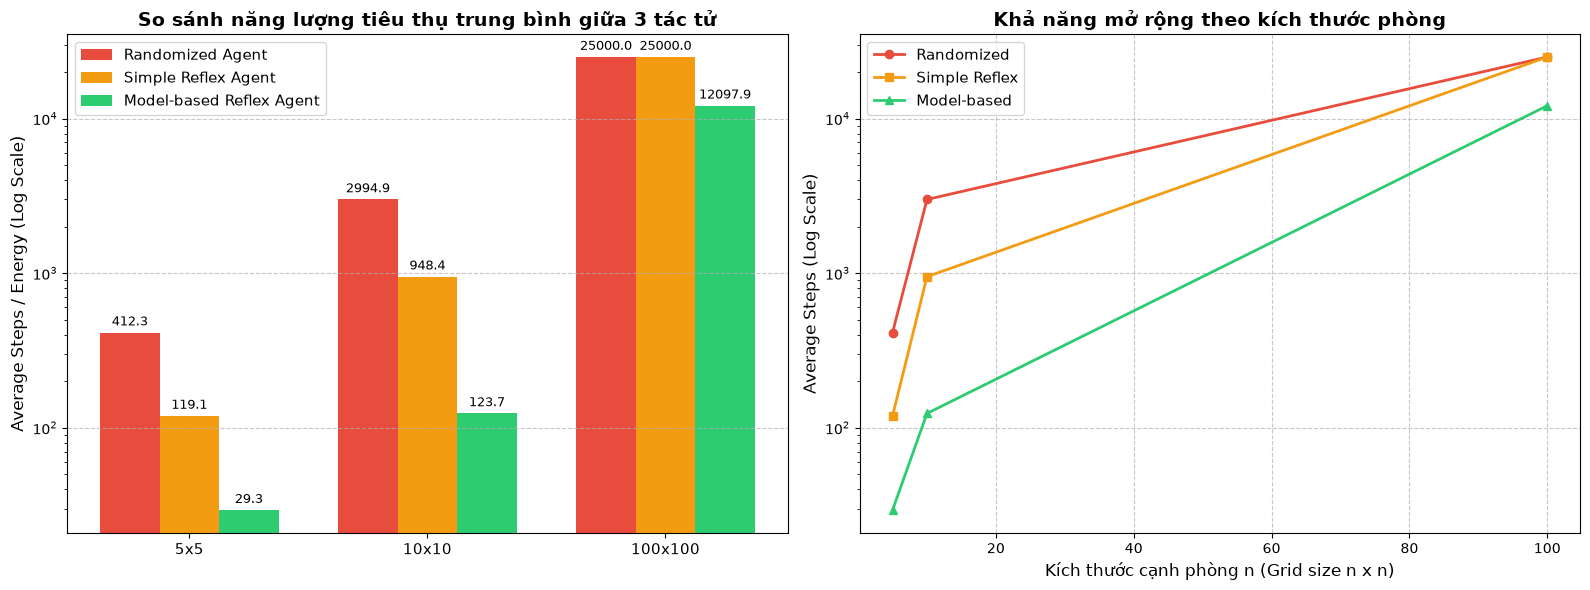

In [ ]:
# Your graphs and discussion of the results goes here
import matplotlib.pyplot as plt

# Thiết lập kích thước đồ thị
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ cột so sánh số bước trung bình (Log scale do 100x100 chênh lệch quá lớn)
x = np.arange(len(sizes))
width = 0.25

rects1 = axes[0].bar(x - width, df_results["Randomized Agent"], width, label='Randomized Agent', color='#e74c3c')
rects2 = axes[0].bar(x, df_results["Simple Reflex Agent"], width, label='Simple Reflex Agent', color='#f39c12')
rects3 = axes[0].bar(x + width, df_results["Model-based Reflex Agent"], width, label='Model-based Reflex Agent',
color='#2ecc71')

axes[0].set_ylabel('Average Steps / Energy (Log Scale)', fontsize=12)
axes[0].set_title('So sánh năng lượng tiêu thụ trung bình giữa 3 tác tử', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{s}x{s}" for s in sizes], fontsize=11)
axes[0].set_yscale('log')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Ghi chú giá trị lên đỉnh các cột
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        axes[0].annotate(f'{height:.1f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, rotation=0)

# 2. Biểu đồ đường thể hiện tốc độ tăng chi phí theo kích thước lưới (Scaleability)
axes[1].plot([5, 10, 100], df_results["Randomized Agent"], marker='o', label='Randomized', color='#e74c3c',
linewidth=2)
axes[1].plot([5, 10, 100], df_results["Simple Reflex Agent"], marker='s', label='Simple Reflex', color='#f39c12',
linewidth=2)
axes[1].plot([5, 10, 100], df_results["Model-based Reflex Agent"], marker='^', label='Model-based',
color='#2ecc71', linewidth=2)

axes[1].set_xlabel('Kích thước cạnh phòng n (Grid size n x n)', fontsize=12)
axes[1].set_ylabel('Average Steps (Log Scale)', fontsize=12)
axes[1].set_title('Khả năng mở rộng theo kích thước phòng', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Thảo luận và Đánh giá Kết quả Thực nghiệm

1. **Randomized Agent (Kém hiệu quả nhất):** - Không có bộ nhớ và bỏ qua cảm biến bụi/tường: robot liên tục đâm vào tường và có thể đi qua ô bẩn mà không
   hút. - Chi phí năng lượng tăng theo hàm số mũ khi kích thước phòng tăng. Ở phòng $100 \times 100$, tác tử hoàn toàn
   không thể làm sạch phòng và luôn chạm trần 25.000 bước.

2. **Simple Reflex Agent (Cải thiện rõ rệt ở phòng nhỏ, bất lực ở phòng lớn):** - Tốt hơn hẳn Randomized Agent vì sở hữu luật điều kiện: gặp bẩn là hút ngay và không đâm vào tường. - Ở phòng nhỏ ($5 \times 5$), tác tử hoàn thành nhiệm vụ khá nhanh. - Tuy nhiên, vì thiếu bộ nhớ (stateless), việc di chuyển vẫn là bước đi ngẫu nhiên (random walk). Theo lý
   thuyết bước đi ngẫu nhiên trong đồ thị 2D, thời gian phủ kín (cover time) rất lớn. Do đó ở phòng $100 \times 100$,
   tác tử đi lặp lại những ô đã sạch vô số lần và cũng chạm trần năng lượng.

3. **Model-Based Reflex Agent (Vượt trội và tối ưu tuyệt đối):** - Nhờ có **trạng thái bên trong** ghi nhớ vị trí và chiến lược quét phủ kín có hệ thống (zíc-zắc), tác tử đi
   qua mỗi ô vuông đúng 1 lần. - Độ phức tạp thời gian/năng lượng là tối ưu tuyến tính theo diện tích phòng: $\mathcal{O}(n^2)$ bước quét +
   $\mathcal{O}(n)$ bước định vị ban đầu + số bước hút bụi. - Tại phòng $100 \times 100$, tác tử hoàn thành sạch sẽ toàn bộ 10.000 ô với chỉ khoảng ~12.000 bước, thể hiện
   tính ổn định 100% trong mọi lần chạy.


## Task 5: Robustness of the agent implementations [10 Points]

Describe how **your agent implementations** will perform

- if it is put into a rectangular room with unknown size,
- if the cleaning area can have an irregular shape (e.g., a hallway connecting two rooms), or
- if the room contains obstacles (i.e., squares that it cannot pass through and trigger the bumper sensors).
- if the dirt sensor is not perfect and gives 10% of the time a wrong reading (clean when it is dirty or dirty when it is clean).
- if the bumper sensor is not perfect and 10% of the time does not report a wall when there is one.


In [17]:
# Answers goes here

### Phân tích chi tiết 5 kịch bản

#### 1. Phòng hình chữ nhật kích thước chưa biết (M × N)

- Randomized Agent: Không bị ảnh hưởng về mặt thuật toán vì tác tử vốn dĩ chọn hướng ngẫu nhiên không phụ thuộc vào
  kích thước phòng. Tuy nhiên, thời gian dọn sạch vẫn cực kỳ kém.
- Simple Reflex Agent: Hoạt động hoàn toàn bình thường. Luật chỉ dựa vào cảm biến cục bộ (bumpers, dirty), thấy biên
  ở đâu thì né ở đó, không phụ thuộc vào phòng vuông hay chữ nhật.
- Model-Based Agent:
  - Pha định vị: Vẫn tìm về góc Tây Bắc (0, 0) thành công vì chỉ cần đi lên Bắc đến khi chạm tường, rồi sang Tây
    đến khi chạm tường.
  - Pha quét: Vì thuật toán đổi hàng dựa trên cảm biến va chạm thực tế (bumpers['east'] hoặc bumpers['west']) chứ
    không cố định số bước bằng N, nên robot vẫn quét được phòng chữ nhật M × N dựa vào các quét zic-zac.

──────

#### 2. Khu vực dọn dẹp có hình dạng bất quy tắc (ví dụ: hành lang nối 2 phòng, hình chữ L)

- Randomized & Simple Reflex Agent: Về mặt lý thuyết xác suất, nếu số bước đủ lớn thì bước đi ngẫu nhiên (random
  walk) vẫn có thể vô tình đi lọt qua hành lang hẹp để sang phòng bên cạnh. Tuy nhiên, trên thực tế, tác tử sẽ tốn lượng năng lượng khổng lồ hoặc cạn pin trước khi làm sạch cả 2 phòng.
- Model-Based Agent (Thất bại):
  - Chiến lược quét zíc-zắc giả định không gian phòng là một hình lồi (convex space).
  - Khi gặp tường nhô ra của hình chữ L hoặc hành lang, robot chạm tường và lầm tưởng đã hết hàng, nó sẽ tự động
    rẽ xuống south → bỏ sót hoàn toàn phần không gian thụt vào sau bức tường.
  - Tác tử không có khả năng quay lại khám phá phòng còn lại nếu không được trang bị thuật toán tìm đường (DFS /
    BFS hoặc Occupancy Grid Mapping).

──────

#### 3. Phòng chứa chướng ngại vật (Vật cản trigger cảm biến va chạm)

- Randomized Agent: Xem vật cản như tường, vẫn đổi hướng ngẫu nhiên.
- Simple Reflex Agent: Nhờ có bumpers, robot sẽ không đâm xuyên qua vật cản mà chọn hướng đi khác. Tuy nhiên, nếu có
  các vật cản tạo thành góc cụt (dead ends / U-shaped traps), robot có thể bị dao động qua lại giữa các ô này rất lâu
  trước khi thoát ra.
- Model-Based Agent (Thất bại hoàn toàn):
  - Khi đang quét ngang mà đâm trúng vật cản ở giữa phòng, bumpers báo True → Robot hiểu nhầm là đã chạm tường
    biên của phòng.
  - Robot lập tức chuyển hướng xuống hàng dưới và đảo chiều quét → Bỏ qua toàn bộ nửa hàng còn lại phía sau vật
    cản.
  - Bản đồ tọa độ nội bộ (pos) bị sai lệch nghiêm trọng so với thực tế. Robot hoàn toàn mất phương hướng và không
    thể hoàn thành nhiệm vụ.

──────

#### 4. Cảm biến bụi bị nhiễu 10% (Imperfect Dirt Sensor)

- Randomized Agent: Vốn không đọc cảm biến bụi khi di chuyển nên chuyển động không đổi.
- Simple Reflex Agent (Bền vững bất ngờ):
  - Trường hợp báo bẩn giả (False Positive): Robot hút ô sạch → Lãng phí 1 năng lượng.
  - Trường hợp bỏ sót bụi (False Negative - 10%): Robot đi qua ô bẩn mà không hút. Nhưng vì tác tử di chuyển ngẫu
    nhiên và ghé thăm lại ô này nhiều lần, ở lần sau xác suất đọc đúng là 90% → Căn phòng cuối cùng vẫn được dọn
    sạch 100%.
- Model-Based Agent (Bị lỗi nghiêm trọng):
  - Robot được thiết kế tối ưu để chỉ đi qua mỗi ô đúng 1 lần duy nhất.
  - Nếu tại một ô bẩn mà cảm biến rơi vào 10% đọc sai (báo sạch) → Robot bỏ qua và không bao giờ quay lại ô này
    nữa.
  - Kết quả: Căn phòng không bao giờ sạch hoàn toàn, vòng lặp mô phỏng sẽ phải chạy hết max_steps mà vẫn thất bại.

──────

#### 5. Cảm biến va chạm bị nhiễu 10% (Không báo tường khi đang ở sát tường)

- Randomized Agent: Không bị ảnh hưởng vì không dùng bumpers.
- Simple Reflex Agent: 10% trường hợp sát tường robot sẽ chọn nhầm hướng đâm vào tường → Đứng yên tại chỗ, tốn 1
  năng lượng lãng phí. Nhưng ở bước sau nó sẽ chọn lại hướng khác, không ảnh hưởng đến khả năng dọn sạch toàn cục.
- Model-Based Agent (Mất đồng bộ hệ quy chiếu - Desynchronization):
  - Khi robot đã chạm biên tường Đông/Tây, nếu cảm biến bị lỗi không báo chạm tường → Robot tiếp tục ra lệnh đi
    ngang tiếp → Robot bị tường chặn đứng lại trong thực tế, nhưng biến trạng thái nội bộ lại tự cộng thêm tọa độ
    (pos[1] += 1).
  - Robot và môi trường bị lệch pha tọa độ. Hơn nữa, vì không nhận được tín hiệu va chạm biên, robot sẽ không kích
    hoạt hành động đi xuống south để đổi hàng, dẫn đến bị kẹt liên tục ở góc tường.


## Advanced task: Imperfect Dirt Sensor

- **Students** need to complete this task [10 points]

1. Change your simulation environment to run experiments for the following problem: The dirt sensor has a 10% chance of giving the wrong reading. Perform experiments to observe how this changes the performance of the three implementations. Your model-based reflex agent is likely not able to clean the whole room, so you need to measure performance differently as a tradeoff between energy cost and number of uncleaned squares.

2. Design an implement a solution for your model-based agent that will clean better. Show the improvement with experiments.


In [37]:
# Your code and discussion goes here
def imperfect_dirt_environment(
    agent_function,
    n=5,
    p=0.2,
    max_steps=1000,
    sensor_error=0.10,
    verbose=False
):
    """
    Simulate Robot Vacuum with an imperfect dirt sensor.

    Parameters
    ----------
    agent_function : callable
        Agent receiving (bumpers, perceived_dirty).

    n : int
        Room size (n x n).

    p : float
        Initial probability that a cell is dirty.

    max_steps : int
        Maximum energy budget.

    sensor_error : float
        Probability that the dirt sensor returns the wrong reading.

    verbose : bool
        Whether to display the simulation.

    Returns
    -------
    dict
        Performance metrics.
    """

    # ============================================================
    # 1. INITIALIZE ENVIRONMENT
    # ============================================================

    grids = np.random.choice(
        [0, 1],
        size=(n, n),
        p=[1 - p, p]
    )

    robot_position = tuple(
        np.random.randint(0, n, size=2)
    )

    initial_dirty = int(np.sum(grids))

    if verbose:
        print("=== INITIAL ENVIRONMENT ===")
        display_environment(grids)

        print("\n=== INITIAL ENVIRONMENT WITH ROBOT ===")
        display_environment(grids, robot_position)
        print()

    # Room already clean
    if initial_dirty == 0:
        return {
            "steps": 0,
            "energy": 0,
            "remaining_dirty": 0,
            "cleaned": 0,
            "cleaning_rate": 1.0,
            "success": True
        }

    # ============================================================
    # 2. SIMULATION
    # ============================================================

    step = 0

    for step in range(max_steps):

        current_pos = robot_position

        # --------------------------------------------------------
        # A. TRUE BUMPER PERCEPT
        # --------------------------------------------------------

        bumpers = {
            "north": current_pos[0] == 0,
            "south": current_pos[0] == n - 1,
            "west": current_pos[1] == 0,
            "east": current_pos[1] == n - 1
        }

        # --------------------------------------------------------
        # B. TRUE DIRT STATE
        # --------------------------------------------------------

        actual_dirty = bool(grids[current_pos] == 1)

        # --------------------------------------------------------
        # C. IMPERFECT DIRT SENSOR
        # --------------------------------------------------------

        perceived_dirty = actual_dirty

        if np.random.random() < sensor_error:
            perceived_dirty = not actual_dirty

        # --------------------------------------------------------
        # D. AGENT DECISION
        # --------------------------------------------------------

        action = agent_function(
            bumpers,
            perceived_dirty
        )

        # --------------------------------------------------------
        # E. EXECUTE ACTION
        # --------------------------------------------------------

        if action == "suck":

            # IMPORTANT:
            # Environment uses TRUE state, not sensor perception.

            if actual_dirty:
                grids[current_pos] = 0

        elif action == "north":

            if not bumpers["north"]:
                robot_position = (
                    current_pos[0] - 1,
                    current_pos[1]
                )

        elif action == "south":

            if not bumpers["south"]:
                robot_position = (
                    current_pos[0] + 1,
                    current_pos[1]
                )

        elif action == "west":

            if not bumpers["west"]:
                robot_position = (
                    current_pos[0],
                    current_pos[1] - 1
                )

        elif action == "east":

            if not bumpers["east"]:
                robot_position = (
                    current_pos[0],
                    current_pos[1] + 1
                )

        # --------------------------------------------------------
        # F. VERBOSE LOG
        # --------------------------------------------------------

        if verbose:

            print(
                f"Step {step + 1}: "
                f"ActualDirty={actual_dirty}, "
                f"PerceivedDirty={perceived_dirty}, "
                f"Action={action}"
            )

            display_environment(
                grids,
                robot_position
            )

            print("-" * 40)

        # --------------------------------------------------------
        # G. CHECK SUCCESS
        # --------------------------------------------------------

        remaining_dirty = int(np.sum(grids))

        if remaining_dirty == 0:

            return {
                "steps": step + 1,
                "energy": step + 1,
                "remaining_dirty": 0,
                "cleaned": initial_dirty,
                "cleaning_rate": 1.0,
                "success": True
            }

    # ============================================================
    # 3. MAX STEPS REACHED
    # ============================================================

    remaining_dirty = int(np.sum(grids))

    cleaned = initial_dirty - remaining_dirty

    cleaning_rate = (
        cleaned / initial_dirty
        if initial_dirty > 0
        else 1.0
    )

    return {
        "steps": max_steps,
        "energy": max_steps,
        "remaining_dirty": remaining_dirty,
        "cleaned": cleaned,
        "cleaning_rate": cleaning_rate,
        "success": remaining_dirty == 0
    }

In [38]:
def performance_score(
    energy,
    remaining_dirty,
    max_steps,
    n,
    energy_weight=0.3,
    dirt_weight=0.7
):
    """
    Higher score = better performance.
    """

    energy_cost = energy / max_steps

    dirt_cost = remaining_dirty / (n * n)

    score = 1 - (
        energy_weight * energy_cost
        + dirt_weight * dirt_cost
    )

    return max(0.0, score)

In [39]:
def run_imperfect_sensor_experiment(
    agents,
    n=5,
    p=0.2,
    sensor_error=0.10,
    max_steps=1000,
    runs=100
):
    results = []

    for agent_name, agent in agents.items():

        for run in range(runs):

            # Reset model-based agent
            if hasattr(agent, "reset"):
                agent.reset()

            result = imperfect_dirt_environment(
                agent_function=agent,
                n=n,
                p=p,
                max_steps=max_steps,
                sensor_error=sensor_error,
                verbose=False
            )

            result["agent"] = agent_name
            result["run"] = run + 1

            results.append(result)

    return pd.DataFrame(results)

In [40]:
model_based_agent = ModelBasedReflexAgent(n=5)

agents = {
    "Randomized": simple_randomized_agent,
    "Simple Reflex": simple_reflex_agent,
    "Model-Based": model_based_agent
}

In [41]:
results = run_imperfect_sensor_experiment(
    agents,
    n=5,
    p=0.2,
    sensor_error=0.10,
    max_steps=1000,
    runs=100
)

In [42]:
summary = (
    results
    .groupby("agent")
    .agg(
        avg_energy=("energy", "mean"),
        avg_remaining_dirty=("remaining_dirty", "mean"),
        avg_cleaning_rate=("cleaning_rate", "mean"),
        success_rate=("success", "mean")
    )
    .reset_index()
).sort_values(by="avg_cleaning_rate", ascending=False)

# Chuyển thành DataFrame và hiển thị bảng kết quả
df_results = pd.DataFrame(summary)

print("\n=== BẢNG KẾT QUẢ TRUNG BÌNH (AVERAGE STEPS / ENERGY CONSUMED) ===")
display(df_results)


=== BẢNG KẾT QUẢ TRUNG BÌNH (AVERAGE STEPS / ENERGY CONSUMED) ===


,agent,avg_energy,avg_remaining_dirty,avg_cleaning_rate,success_rate
2,Simple Reflex,133.42,0.00,1.000000,1.00
1,Randomized,385.07,0.06,0.986333,0.95
0,Model-Based,225.94,0.22,0.952702,0.80


In [43]:
results

,steps,energy,remaining_dirty,cleaned,cleaning_rate,success,agent,run
0,879,879,0,4,1.00,True,Randomized,1
1,220,220,0,4,1.00,True,Randomized,2
2,229,229,0,3,1.00,True,Randomized,3
3,1000,1000,1,1,0.50,False,Randomized,4
4,438,438,0,5,1.00,True,Randomized,5
...,...,...,...,...,...,...,...,...
295,1000,1000,1,3,0.75,False,Model-Based,96
296,12,12,0,3,1.00,True,Model-Based,97
297,32,32,0,4,1.00,True,Model-Based,98
298,38,38,0,5,1.00,True,Model-Based,99


## More Advanced Implementation (not for credit)

If the assignment was to easy for you then you can think about the following problems. These problems are challenging and not part of this assignment. We will learn implementation strategies and algorithms useful for these tasks during the rest of the semester.

- **Obstacles:** Change your simulation environment to run experiments for the following problem: Add random obstacle squares that also trigger the bumper sensor. The agent does not know where the obstacles are. Perform experiments to observe how this changes the performance of the three implementations. Describe what would need to be done to perform better with obstacles. Add code if you can.

- **Agent for and environment with obstacles:** Implement an agent for an environment where the agent does not know how large the environment is (we assume it is rectangular), where it starts or where the obstacles are. An option would be to always move to the closest unchecked/uncleaned square (note that this is actually depth-first search).

- **Utility-based agent:** Change the environment for a $5 \times 5$ room, so each square has a fixed probability of getting dirty again. For the implementation, we give the environment a 2-dimensional array of probabilities. The utility of a state is defined as the number of currently clean squares in the room. Implement a utility-based agent that maximizes the expected utility over one full charge which lasts for 100000 time steps. To do this, the agent needs to learn the probabilities with which different squares get dirty again. This is very tricky!


In [52]:
class ImprovedImperfectSensorAgent(ModelBasedReflexAgent):
        """
        Tác tử Model-Based cải tiến giải quyết cảm biến bụi bị nhiễu 10%.
        Chiến lược: Quét 2 lượt có hệ thống (Two-Pass Systematic Sweep).
        - Lượt 1: Quét từ (0, 0) xuống (n-1, n-1).
        - Lượt 2: Quét ngược từ dưới lên trên để rà soát lại (Re-scan).
        - Tỷ lệ bỏ sót giảm từ 10% xuống chỉ còn 1% (0.1 * 0.1).
        """
        def __init__(self, n=5, sensor_error=0.10):
            super().__init__(n)
            self.sensor_error = sensor_error
            self.reset()

        def reset(self):
            super().reset()
            self.phase = "GO_NORTH"
            self.pos = [None, None]
            self.sweep_dir = "east"

        def __call__(self, bumpers, perceived_dirty):
            # 1. Nhận tín hiệu trực tiếp từ môi trường (không inject nhiễu lần 2)
            if perceived_dirty:
                return "suck"

            # 2. Pha định vị ban đầu đưa robot về góc Tây-Bắc (0, 0)
            if self.phase == "GO_NORTH":
                if not bumpers["north"]:
                    return "north"
                else:
                    self.phase = "GO_WEST"
                    self.pos[0] = 0
                    return "west" if not bumpers["west"] else "suck"

            if self.phase == "GO_WEST":
                if not bumpers["west"]:
                    return "west"
                else:
                    self.pos[1] = 0
                    self.phase = "SWEEP_DOWN"
                    self.sweep_dir = "east"

            # 3. Lượt 1: Quét zíc-zắc từ trên xuống dưới (Top-Down Sweep)
            if self.phase == "SWEEP_DOWN":
                if self.sweep_dir == "east":
                    if not bumpers["east"]:
                        self.pos[1] += 1
                        return "east"
                    else:
                        if not bumpers["south"]:
                            self.sweep_dir = "west"
                            self.pos[0] += 1
                            return "south"
                        else:
                            # Đã chạm đáy phòng (hàng n-1, cột n-1). Đảo chiều quét ngược lên trên!
                            self.phase = "SWEEP_UP"
                            self.sweep_dir = "west"
                elif self.sweep_dir == "west":
                    if not bumpers["west"]:
                        self.pos[1] -= 1
                        return "west"
                    else:
                        if not bumpers["south"]:
                            self.sweep_dir = "east"
                            self.pos[0] += 1
                            return "south"
                        else:
                            # Đã chạm đáy phòng (hàng n-1, cột 0). Đảo chiều quét ngược lên trên!
                            self.phase = "SWEEP_UP"
                            self.sweep_dir = "east"

            # 4. Lượt 2: Quét zíc-zắc ngược từ dưới lên trên (Bottom-Up Re-visit)
            if self.phase == "SWEEP_UP":
                if self.sweep_dir == "east":
                    if not bumpers["east"]:
                        self.pos[1] += 1
                        return "east"
                    else:
                        if not bumpers["north"]:
                            self.sweep_dir = "west"
                            self.pos[0] -= 1
                            return "north"
                        else:
                            self.phase = "REFLEX_CLEAN"
                elif self.sweep_dir == "west":
                    if not bumpers["west"]:
                        self.pos[1] -= 1
                        return "west"
                    else:
                        if not bumpers["north"]:
                            self.sweep_dir = "east"
                            self.pos[0] -= 1
                            return "north"
                        else:
                            self.phase = "REFLEX_CLEAN"

            # 5. Fallback thông minh: Simple Reflex (không đâm tường) nếu sau 2 lượt vẫn còn sót ô
            valid_actions = [d for d, b in bumpers.items() if not b]
            return np.random.choice(valid_actions)

In [54]:
improved_agent = ImprovedImperfectSensorAgent(n=5, sensor_error=0.10)
agents = {
    "Randomized": simple_randomized_agent,
    "Simple Reflex": simple_reflex_agent,
    "Improved Model-Based": improved_agent
}

In [55]:
results = run_imperfect_sensor_experiment(
    agents,
    n=5,
    p=0.2,
    sensor_error=0.10,
    max_steps=1000,
    runs=100
)

In [56]:
summary = (
    results
    .groupby("agent")
    .agg(
        avg_energy=("energy", "mean"),
        avg_remaining_dirty=("remaining_dirty", "mean"),
        avg_cleaning_rate=("cleaning_rate", "mean"),
        success_rate=("success", "mean")
    )
    .reset_index()
).sort_values(by="avg_cleaning_rate", ascending=False)

# Chuyển thành DataFrame và hiển thị bảng kết quả
df_results = pd.DataFrame(summary)

print("\n=== BẢNG KẾT QUẢ TRUNG BÌNH (AVERAGE STEPS / ENERGY CONSUMED) ===")
display(df_results)


=== BẢNG KẾT QUẢ TRUNG BÌNH (AVERAGE STEPS / ENERGY CONSUMED) ===


,agent,avg_energy,avg_remaining_dirty,avg_cleaning_rate,success_rate
0,Improved Model-Based,41.61,0.00,1.0000,1.00
2,Simple Reflex,122.09,0.00,1.0000,1.00
1,Randomized,389.96,0.01,0.9975,0.99
